In [1]:
import sys
sys.path.append('../')

import torch
from torch.utils.data import Dataset, DataLoader, Subset
import numpy as np

import matplotlib.pyplot as plt

# Dataset

In [2]:
import uproot

class CaloDataset(Dataset):

    def __init__(self, data_file_path,
                    Nx = 128, Ny = 128, Nz = 64,
                    downsample_factors: list | None = None):

        self.Nx = Nx
        self.Ny = Ny
        self.Nz = Nz
        if downsample_factors is not None:
            assert len(downsample_factors) == 3
            for dsf in downsample_factors:
                assert Nx % dsf == 0
                assert Ny % dsf == 0
                assert Nz % dsf == 0
            self.dsfs = downsample_factors

        with uproot.open(data_file_path) as f:
            tree = f["Cells"]
            self.data = tree.arrays(["cell_e_dep", 
                                     "cell_idx_x", 
                                     "cell_idx_y", 
                                     "cell_idx_z"], 
                                    library="np")

    def __len__(self):
        return len(self.data)

    def pad_single_example(self, e, idx_x, idx_y, idx_z):

        ### Create 3D voxel grid from sparse representation
        voxels = torch.zeros(self.Nx, self.Ny, self.Nz, dtype=torch.float32)

        voxels[idx_x, idx_y, idx_z] = torch.tensor(e, dtype=torch.float32)
        return voxels
    
    def downsample_single_example(self, voxels, dsfs):

        ### sum pooling to downsample
        dsf_x, dsf_y, dsf_z = dsfs
        voxels = voxels.unfold(0, dsf_x, dsf_x).sum(dim=-1)
        voxels = voxels.unfold(1, dsf_y, dsf_y).sum(dim=-1)
        voxels = voxels.unfold(2, dsf_z, dsf_z).sum(dim=-1)

        return voxels

    def __getitem__(self, idx, downsample=True):
    
        e = self.data["cell_e_dep"][idx]
        idx_x = self.data["cell_idx_x"][idx]
        idx_y = self.data["cell_idx_y"][idx]
        idx_z = self.data["cell_idx_z"][idx]

        voxels = self.pad_single_example(e, idx_x, idx_y, idx_z)

        if downsample:
            voxels = self.downsample_single_example(voxels, self.dsfs)

        ### put layer dimension first (channel)
        voxels = voxels.permute(2, 0, 1)

        voxels = voxels[:1, :, :] # HACK: using only first layer for 2D FNO

        return voxels


In [3]:
data_file_path = "/storage/agrp/dreyet/FastCaloSim/Geant4/B4/build/B4c/electron_showers_5GeV_10k_128_128_64.root"

dataset = CaloDataset(data_file_path, downsample_factors=[2,2,2])

Low-res shape: torch.Size([1, 64, 64])
High-res shape: torch.Size([1, 128, 128])


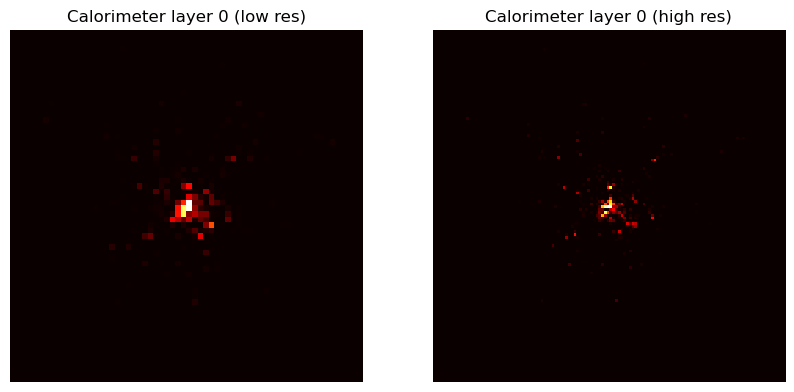

In [4]:
example_idx = 1
layer_idx = 0

x_low = dataset[example_idx]
x_high = dataset.__getitem__(example_idx, downsample=False)

print(f"Low-res shape: {x_low.shape}")
print(f"High-res shape: {x_high.shape}")

fig, ax = plt.subplots(1, 2, figsize=(10,5))

ax[0].imshow(x_low[layer_idx, :, :].numpy(), cmap='hot', interpolation='none')
ax[0].set_title(f'Calorimeter layer {layer_idx} (low res)')
ax[0].axis('off')

ax[1].imshow(x_high[layer_idx, :, :].numpy(), cmap='hot', interpolation='none')
ax[1].set_title(f'Calorimeter layer {layer_idx} (high res)')
ax[1].axis('off')

plt.show()

# Model

In [5]:
n_x = 64
dims = [n_x, n_x]

device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

# FNO hyperparameters
modes = 32 
width = 128
mlp_width = 128

# GP hyperparameters
kernel_length=0.01
kernel_variance=1
nu = 0.5 # default

## training parameters
epochs = 20
sigma_min=1e-4
batch_size = 10

Using device: cpu


In [6]:
from models.fno import FNO

model = FNO(modes, vis_channels=1, hidden_channels=width, proj_channels=mlp_width, x_dim=2, t_scaling=1).to(device)

# Training

In [7]:
dataset_tr = Subset(dataset, np.arange(10))
loader_tr = DataLoader(dataset_tr, batch_size=batch_size, shuffle=True)

In [8]:
from ofm_OT_likelihood import OFMModel

fmot = OFMModel(model, kernel_length=kernel_length, kernel_variance=kernel_variance, nu=nu, sigma_min=sigma_min, device=device, dims=dims)

In [9]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=epochs//10, gamma=0.8)

In [10]:
from pathlib import Path
save_path = Path(".")

fmot.train(loader_tr, optimizer, epochs=epochs, scheduler=scheduler, eval_int=int(0), save_int=int(2), generate=False, save_path=save_path,saved_model=True)

tr @ epoch 1/20 | Loss 4.591848 | 6.08 (s)
tr @ epoch 2/20 | Loss 4.572972 | 5.64 (s)
tr @ epoch 3/20 | Loss 8.084029 | 5.56 (s)
tr @ epoch 4/20 | Loss 5.537183 | 5.72 (s)
tr @ epoch 5/20 | Loss 5.128558 | 5.51 (s)
tr @ epoch 6/20 | Loss 4.491739 | 5.61 (s)
tr @ epoch 7/20 | Loss 4.313106 | 5.61 (s)
tr @ epoch 8/20 | Loss 4.797835 | 5.61 (s)
tr @ epoch 9/20 | Loss 2.338998 | 5.49 (s)
tr @ epoch 10/20 | Loss 2.925344 | 5.67 (s)
tr @ epoch 11/20 | Loss 2.329104 | 5.60 (s)
tr @ epoch 12/20 | Loss 3.343642 | 5.66 (s)
tr @ epoch 13/20 | Loss 2.747279 | 5.66 (s)
tr @ epoch 14/20 | Loss 2.816431 | 5.52 (s)
tr @ epoch 15/20 | Loss 2.797270 | 5.63 (s)
tr @ epoch 16/20 | Loss 2.453413 | 5.66 (s)
tr @ epoch 17/20 | Loss 4.030300 | 5.49 (s)
tr @ epoch 18/20 | Loss 2.089122 | 5.57 (s)
tr @ epoch 19/20 | Loss 2.083792 | 5.50 (s)
tr @ epoch 20/20 | Loss 3.104777 | 5.61 (s)


# Evaluation

In [12]:
from scipy.stats import binned_statistic

def compute_acovf(z, nlag=50):
    # z shape : [n, ndim, ndim]
    res = z.shape[-1]
    z_hat = torch.fft.rfft2(z)
    acf = torch.fft.irfft2(torch.conj(z_hat) * z_hat)
    acf = torch.fft.fftshift(acf).mean(dim=0) / z[0].numel() # ndim*ndim
    acf_r = acf.view(-1).cpu().detach().numpy()
    lags_x, lags_y = torch.meshgrid(torch.arange(res) - res//2, torch.arange(res) - res//2)
    lags_r = torch.sqrt(lags_x**2 + lags_y**2).view(-1).cpu().detach().numpy()

    idx = np.argsort(lags_r)
    lags_r = lags_r[idx]
    acf_r = acf_r[idx]

    bin_means, bin_edges, binnumber = binned_statistic(lags_r, acf_r, 'mean', bins=np.linspace(0.0, res, nlag))
    return bin_edges[:-1], bin_means

In [21]:
x_train = torch.stack([dataset_tr[i] for i in range(len(dataset_tr))], dim=0)
print(x_train.shape)

torch.Size([10, 1, 64, 64])


0
1
2
3
4


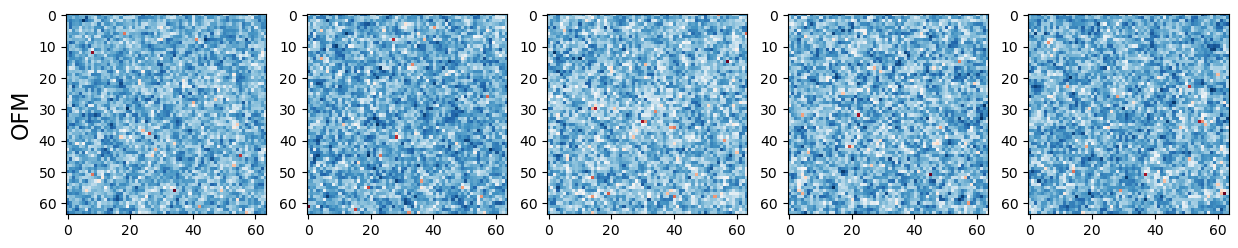

In [22]:
n_samples = 5

with torch.no_grad():

    X_hat = fmot.sample([n_x, n_x], n_samples=n_samples, n_eval=10).cpu()
    X_ground_truth = x_train[:5].squeeze()
    # plot
    
    X_alt = []
    for i in range(5):
        print(i)
        X_temp = fmot.sample([n_x, n_x], n_samples=n_samples, n_eval=10).cpu().squeeze()
        X_alt.append(X_temp)
        
    X_alt = torch.vstack(X_alt)
    #X_alt = torch.exp(X_alt * x_std + x_mean)
    
    bin_center, x_acovf = compute_acovf(X_alt.squeeze())
    #x_train = torch.exp(x_train*x_std + x_mean)
    _, x_acovf_true = compute_acovf(x_train.squeeze())
    x_hist, bin_edges_alt = X_alt.histogram(range=[-4,4], density=True)
    x_hist_true, bin_edges = x_train.histogram(range=[-4, 4], density=True)
    
    fig, ax = plt.subplots(1,5, figsize=(15,3))
    for i in range(5):
        x = X_hat[i,:,:].squeeze()

        ax[i].imshow(x,cmap="RdBu_r")#, vmin=-2, vmax=2)
        if i == 0:
            ax[i].set_ylabel('OFM', fontsize=16)

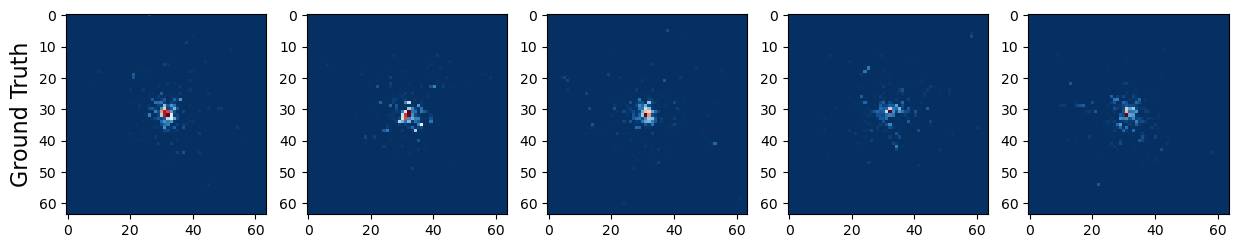

In [24]:
fig, ax = plt.subplots(1,5, figsize=(15,3))    
for i in range(5):
    x_ground_truth = X_ground_truth[i,:,:].squeeze()
    ax[i].imshow(x_ground_truth,cmap="RdBu_r")#, vmin=-2, vmax=2)
    if i == 0:
        ax[i].set_ylabel('Ground Truth', fontsize=16)


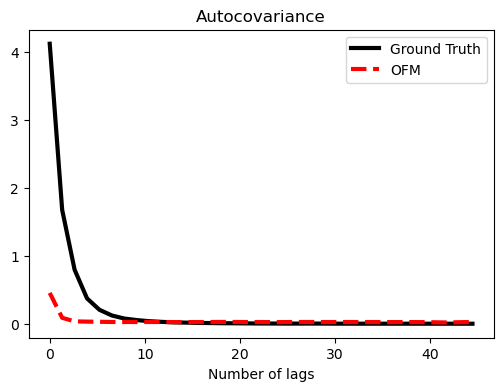

In [25]:
fig, ax = plt.subplots(1,1, figsize=(6,4))
ax.plot(bin_center, x_acovf_true, c='k', lw=3, label='Ground Truth')
ax.plot(bin_center, x_acovf, c='r',ls='--', lw=3, label='OFM')
#ax[0].set_ylim(0.2, 0.45)
ax.set_title('Autocovariance')
ax.set_xlabel('Number of lags')
ax.legend(loc='upper right')